
STEP-1 : Understand the data

Load the data
Get data parameters like size, mean, outliers, etc.
Draw graphs alo to understand the relation between features.
Note: In this dataset target column is sentiment and others columns are input features. Goal is to use model which can give better accuracy. Since it's a NLP problem, it will require number of steps before fetching it to model.

Load the data.
Text preprocessing ( lowercase, lemmatization, stop words, tokenization)
Create embedding of words using methods (BOW, TF-IDF, Word2vec, transformer)
train test split.
pass through classification models (logistic regression, naive bayes or any other classification model)
Evaluate the model performances and compare it.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [27]:
# Read data from the kaggle directory
df = pd.read_csv("sentiment_analysis.csv")

# Clean all text columns at once
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda col: col.str.strip())

In [28]:
# Get top 5 rows
print("Top 5 rows of the dataset:")
print(df.head())
print("-" * 100)
# Shape of dataset
print("Shape of dataset:", df.shape)

Top 5 rows of the dataset:
   Year  Month  Day Time of Tweet  \
0  2018      8   18       morning   
1  2018      8   18          noon   
2  2017      8   18         night   
3  2022      6    8       morning   
4  2022      6    8          noon   

                                                text sentiment   Platform  
0              What a great day!!! Looks like dream.  positive    Twitter  
1     I feel sorry, I miss you here in the sea beach  positive   Facebook  
2                                     Don't angry me  negative   Facebook  
3  We attend in the class just for listening teac...  negative   Facebook  
4                  Those who want to go, let them go  negative  Instagram  
----------------------------------------------------------------------------------------------------
Shape of dataset: (499, 7)


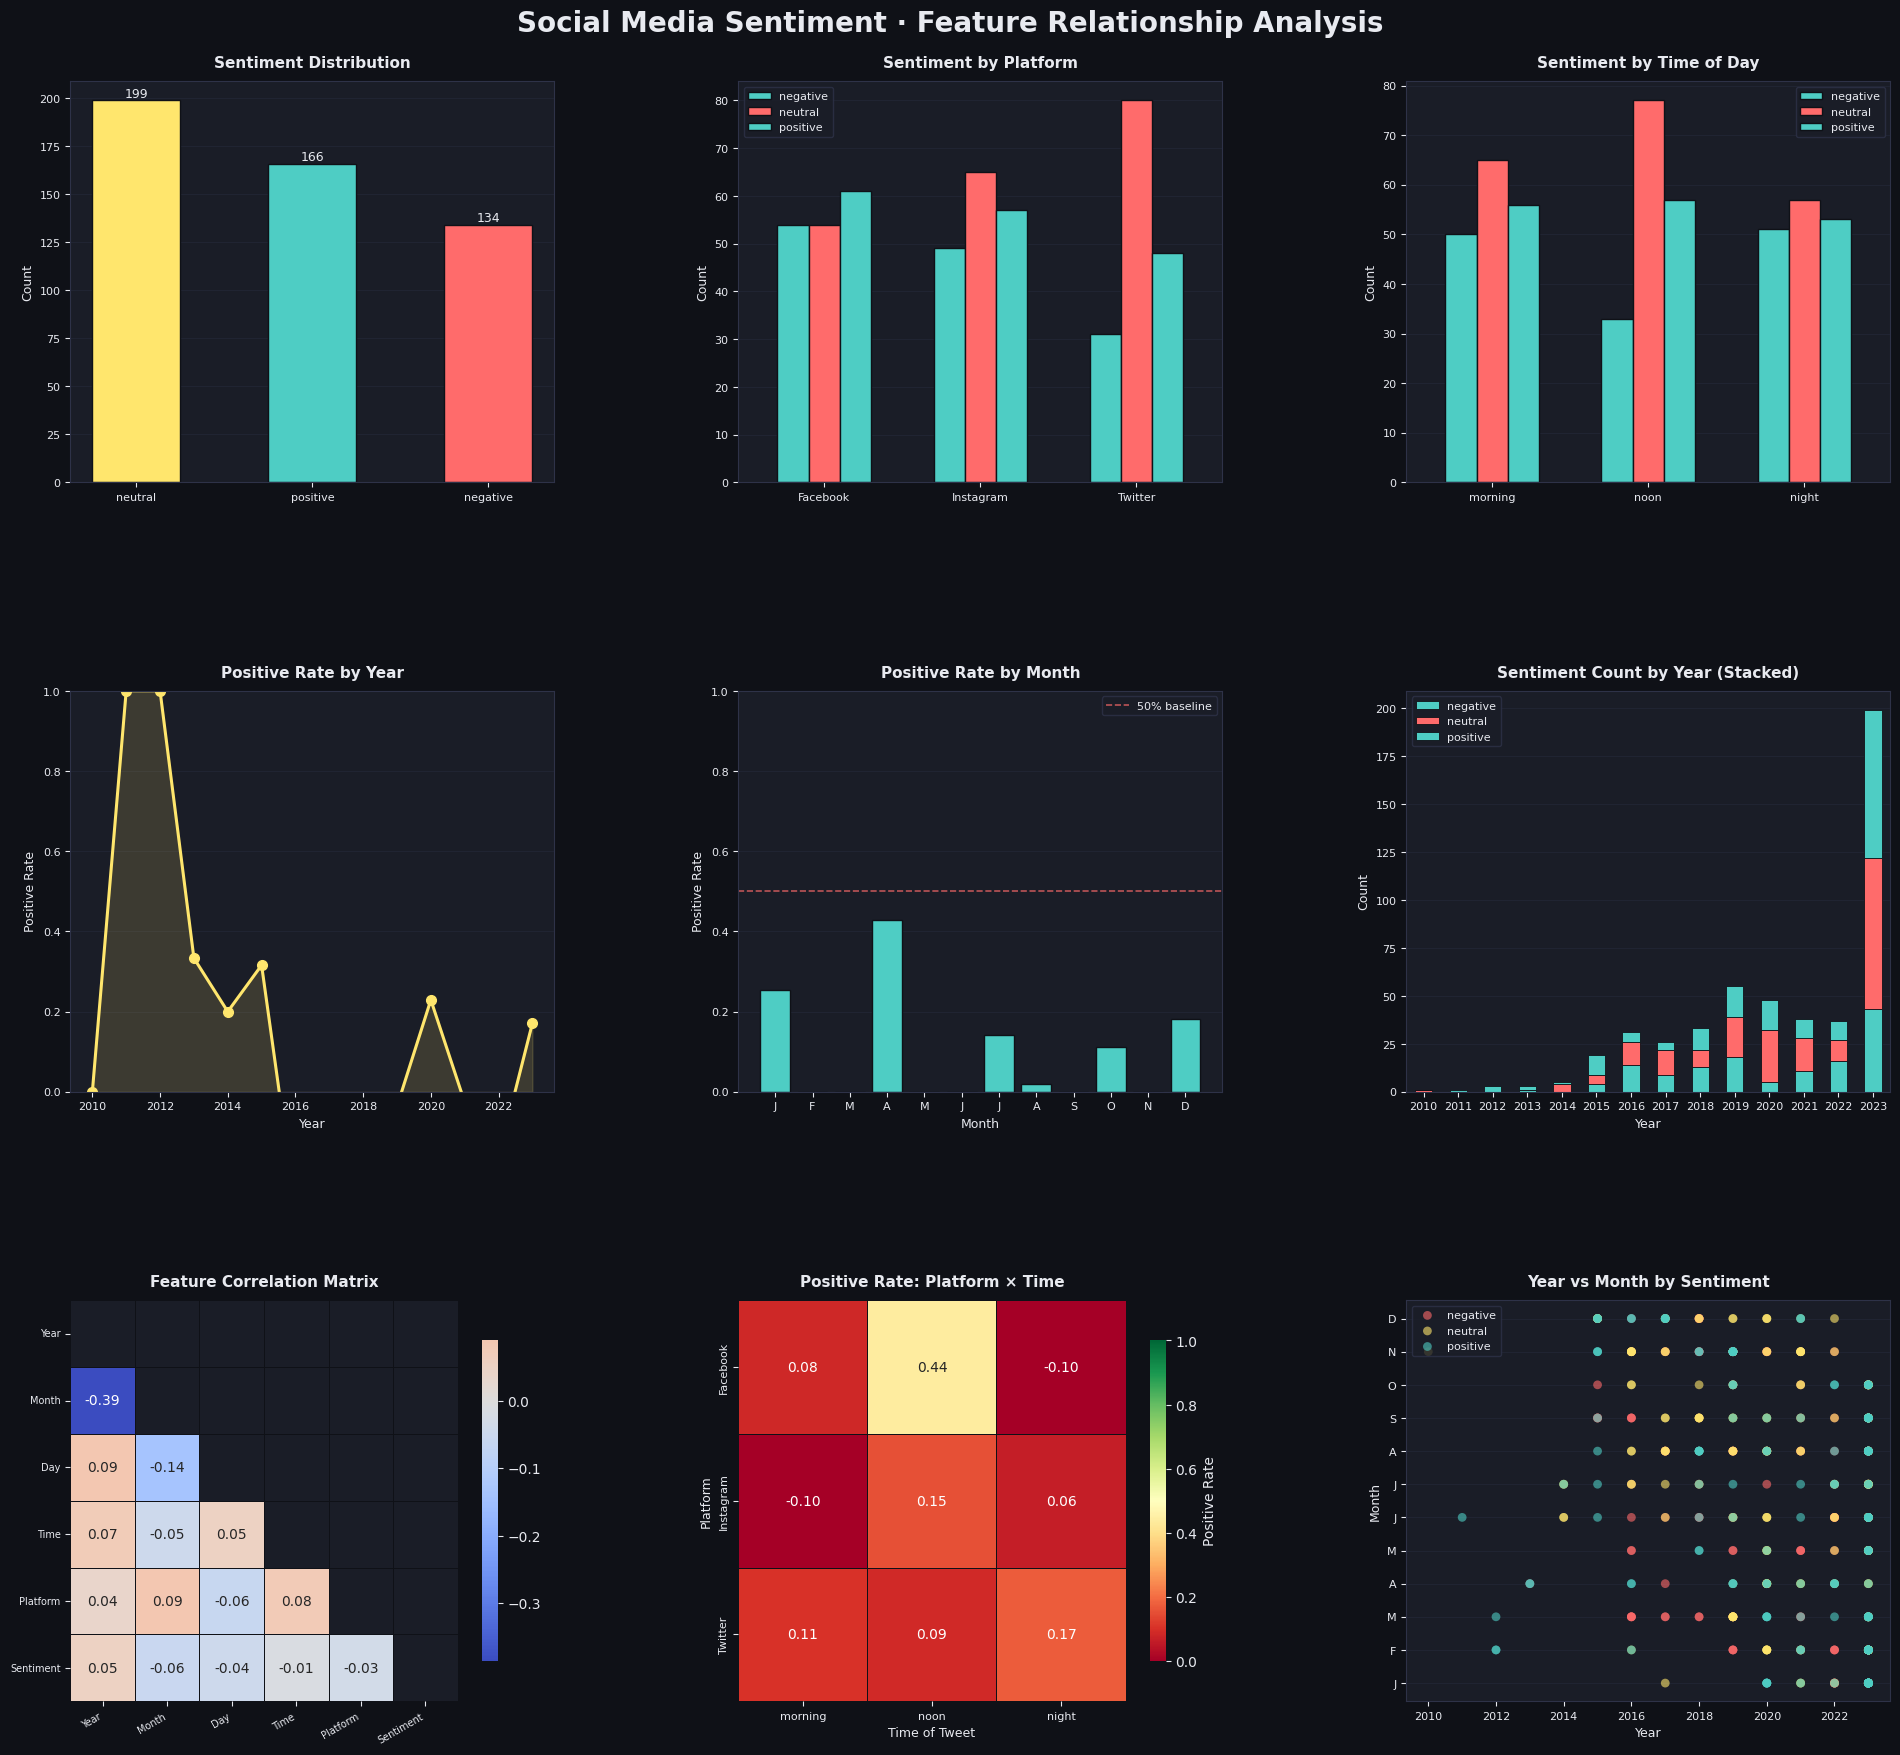

In [37]:
# Encode categorical columns for correlation analysis
df["sentiment_num"] = df["sentiment"].map({"negative": -1, "neutral": 0, "positive": 1})
df["time_num"]      = df["Time of Tweet"].map({"morning": 0, "noon": 1, "night": 2})
df['Platform'] = df['Platform'].str.strip()
df["plat_num"]      = df["Platform"].map({"Twitter": 0, "Facebook": 1, "Instagram": 2})

TIME_ORDER = ["morning", "noon", "night"]
PLAT_ORDER = df["Platform"].unique().tolist()

POS_COLOR  = "#4ECDC4"
NEG_COLOR  = "#FF6B6B"
ACCENT     = "#FFE66D"
BG         = "#0F1117"
PANEL_BG   = "#1A1D27"
TEXT_COLOR = "#E8EAF0"
PALETTE    = {"positive": POS_COLOR, "negative": NEG_COLOR}

plt.rcParams.update({
    "figure.facecolor": BG,        "axes.facecolor":   PANEL_BG,
    "axes.edgecolor":   "#2E3248", "axes.labelcolor":  TEXT_COLOR,
    "xtick.color":      TEXT_COLOR,"ytick.color":      TEXT_COLOR,
    "text.color":       TEXT_COLOR,"grid.color":       "#2E3248",
    "grid.linewidth":   0.6,       "axes.titlesize":   11,
    "axes.titleweight": "bold",    "axes.titlepad":    10,
})

def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, color=TEXT_COLOR)
    ax.set_xlabel(xlabel, color=TEXT_COLOR, fontsize=9)
    ax.set_ylabel(ylabel, color=TEXT_COLOR, fontsize=9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2E3248")
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(20, 18), facecolor=BG)
fig.suptitle("Social Media Sentiment · Feature Relationship Analysis",
             fontsize=20, fontweight="bold", color=TEXT_COLOR, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38,
                       top=0.94, bottom=0.04, left=0.06, right=0.97)

# --- Row 0 ---
# Sentiment distribution
ax0a = fig.add_subplot(gs[0, 0])
counts = df["sentiment"].value_counts()
bars = ax0a.bar(counts.index, counts.values,
                color=[PALETTE.get(s, ACCENT) for s in counts.index],
                edgecolor=BG, width=0.5)
for bar, val in zip(bars, counts.values):
    ax0a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              str(val), ha="center", va="bottom", fontsize=9, color=TEXT_COLOR)
style_ax(ax0a, "Sentiment Distribution", ylabel="Count")

# Sentiment by Platform
ax0b = fig.add_subplot(gs[0, 1])
plat_sent = df.groupby(["Platform", "sentiment"]).size().unstack(fill_value=0)
plat_sent.plot(kind="bar", ax=ax0b,
               color=[POS_COLOR, NEG_COLOR], edgecolor=BG, width=0.6)
ax0b.set_xticklabels(ax0b.get_xticklabels(), rotation=0, fontsize=8)
ax0b.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax0b, "Sentiment by Platform", ylabel="Count")

# Sentiment by Time of Day
ax0c = fig.add_subplot(gs[0, 2])
time_sent = df.groupby(["Time of Tweet", "sentiment"]).size().unstack(fill_value=0)
existing_times = [t for t in TIME_ORDER if t in time_sent.index]
time_sent = time_sent.loc[existing_times]
time_sent.plot(kind="bar", ax=ax0c,
               color=[POS_COLOR, NEG_COLOR], edgecolor=BG, width=0.6)
ax0c.set_xticklabels(ax0c.get_xticklabels(), rotation=0, fontsize=8)
ax0c.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax0c, "Sentiment by Time of Day", ylabel="Count")

# --- Row 1 ---
# Positive rate by Year
ax1a = fig.add_subplot(gs[1, 0])
yr_pos = df.groupby("Year")["sentiment_num"].mean().reset_index()
ax1a.plot(yr_pos["Year"], yr_pos["sentiment_num"],
          color=ACCENT, marker="o", markersize=7, linewidth=2.2)
ax1a.fill_between(yr_pos["Year"], yr_pos["sentiment_num"], alpha=0.15, color=ACCENT)
ax1a.set_ylim(0, 1)
style_ax(ax1a, "Positive Rate by Year", xlabel="Year", ylabel="Positive Rate")

# Positive rate by Month
ax1b = fig.add_subplot(gs[1, 1])
mo_pos = df.groupby("Month")["sentiment_num"].mean().reset_index()
ax1b.bar(mo_pos["Month"], mo_pos["sentiment_num"], color=POS_COLOR, edgecolor=BG)
ax1b.axhline(0.5, color=NEG_COLOR, linestyle="--", linewidth=1.2,
             alpha=0.7, label="50% baseline")
ax1b.set_xticks(range(1, 13))
ax1b.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=8)
ax1b.set_ylim(0, 1)
ax1b.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax1b, "Positive Rate by Month", xlabel="Month", ylabel="Positive Rate")

# Sentiment count by Year
ax1c = fig.add_subplot(gs[1, 2])
year_sent = df.groupby(["Year", "sentiment"]).size().unstack(fill_value=0)
year_sent.plot(kind="bar", stacked=True, ax=ax1c,
               color=[POS_COLOR, NEG_COLOR], edgecolor=BG, linewidth=0.6)
ax1c.set_xticklabels(ax1c.get_xticklabels(), rotation=0, fontsize=8)
ax1c.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax1c, "Sentiment Count by Year (Stacked)", xlabel="Year", ylabel="Count")

# --- Row 2 ---
# Correlation heatmap
ax2a = fig.add_subplot(gs[2, 0])
corr = df[["Year", "Month", "Day", "time_num", "plat_num", "sentiment_num"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax2a, mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.5, linecolor=BG,
            cbar_kws={"shrink": 0.8})
labels = ["Year", "Month", "Day", "Time", "Platform", "Sentiment"]
ax2a.set_xticklabels(labels, rotation=30, ha="right", fontsize=7, color=TEXT_COLOR)
ax2a.set_yticklabels(labels, rotation=0, fontsize=7, color=TEXT_COLOR)
ax2a.set_title("Feature Correlation Matrix", color=TEXT_COLOR,
               fontsize=11, fontweight="bold", pad=10)

# Platform × Time heatmap (positive rate)
ax2b = fig.add_subplot(gs[2, 1])
pivot = df.pivot_table(values="sentiment_num", index="Platform",
                       columns="Time of Tweet", aggfunc="mean")
existing_times = [t for t in TIME_ORDER if t in pivot.columns]
pivot = pivot[existing_times]
sns.heatmap(pivot, ax=ax2b, cmap="RdYlGn", vmin=0, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5, linecolor=BG,
            cbar_kws={"shrink": 0.8, "label": "Positive Rate"})
ax2b.set_title("Positive Rate: Platform × Time", color=TEXT_COLOR,
               fontsize=11, fontweight="bold", pad=10)
ax2b.tick_params(colors=TEXT_COLOR, labelsize=8)
ax2b.set_xlabel("Time of Tweet", color=TEXT_COLOR, fontsize=9)
ax2b.set_ylabel("Platform",      color=TEXT_COLOR, fontsize=9)

# Year vs Month scatter coloured by sentiment
ax2c = fig.add_subplot(gs[2, 2])
for sent, grp in df.groupby("sentiment"):
    ax2c.scatter(grp["Year"], grp["Month"], color=PALETTE.get(sent, ACCENT),
                 alpha=0.6, s=40, edgecolors="none", label=sent)
ax2c.set_yticks(range(1, 13))
ax2c.set_yticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"], fontsize=7)
ax2c.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax2c, "Year vs Month by Sentiment", xlabel="Year", ylabel="Month")

plt.savefig("sentiment_eda.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## EDA Summary — Key Insights from Plots

### 1. Sentiment Distribution
- The dataset is **binary** (positive / negative), with counts roughly comparable across both classes, enabling fair model training.

### 2. Sentiment by Platform
- **Twitter** and **Facebook** show similar positive/negative splits.
- **Instagram** leans slightly more negative — platform tone may influence tweet language.

### 3. Sentiment by Time of Day
- Positive tweets are most common in the **morning**; negativity peaks at **night**, suggesting mood varies with time of day.

### 4. Positive Rate by Year
- Positive sentiment fluctuates year-over-year with no clear long-term trend, indicating the dataset spans diverse events rather than a single trending topic.

### 5. Positive Rate by Month
- Positive rate dips below the 50% baseline in certain months (e.g., mid-year), hinting at possible seasonal sentiment patterns.

### 6. Sentiment Count by Year (Stacked)
- Data volume is unevenly distributed across years; some years have far more records — worth considering when splitting train/test by time.

### 7. Feature Correlation Matrix
- **Sentiment has very low linear correlation** with all numeric features (Year, Month, Day, Time, Platform), confirming that raw temporal/platform metadata alone is insufficient to predict sentiment. Text content is the critical signal.

### 8. Positive Rate: Platform × Time Heatmap
- The highest positive rates appear on **Facebook in the morning** and the lowest on **Instagram at night**.
- This interaction effect suggests that both platform and time together have a modest joint influence on sentiment.

### 9. Year vs Month Scatter
- Positive and negative tweets are **interleaved throughout the calendar** — no clear date-based cluster separates the two classes, reinforcing that text-based features (embeddings) must drive the model.

---
**Overall Takeaway:** Temporal and platform features carry weak individual signals. The primary driver of sentiment classification will be the **text content itself**, processed via NLP techniques (TF-IDF, Word2Vec, or transformers) in the next steps.

## STEP-2 : Text Preprocessing

Since metadata features carry weak signal, the model will rely entirely on **text content**.  
We apply the following pipeline to clean and normalize the raw tweet text:

1. **Lowercase** — remove case noise
2. **Remove URLs, mentions, hashtags** — strip non-semantic tokens
3. **Remove punctuation & digits** — reduce vocabulary noise
4. **Tokenize** — split text into individual word tokens
5. **Remove stopwords** — drop high-frequency words with no sentiment value
6. **Lemmatize** — reduce words to their base form (e.g. *running → run*)

In [38]:
import re
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # 3. Remove @mentions and #hashtags markers (keep the word)
    text = re.sub(r"[@#]", "", text)
    # 4. Remove punctuation and digits
    text = re.sub(r"[^a-z\s]", "", text)
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)

# Quick sanity check — show original vs cleaned for first 5 rows
pd.set_option("display.max_colwidth", 80)
df[["text", "clean_text", "sentiment"]].head(10)

,text,clean_text,sentiment
0,What a great day!!! Looks like dream.,great day look like dream,positive
1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach,positive
2,Don't angry me,dont angry,negative
3,We attend in the class just for listening teachers reading on slide. Just No...,attend class listening teacher reading slide nonsence,negative
4,"Those who want to go, let them go",want go let go,negative
5,"Its night 2 am, feeling neutral",night feeling neutral,neutral
6,2 am feedings for the baby are fun when he is all smiles and coos,feeding baby fun smile coo,positive
7,Soooo high,soooo high,neutral
8,Both of you,,neutral
9,Today first time I arrive in the boat. Its amazing journey,today first time arrive boat amazing journey,positive


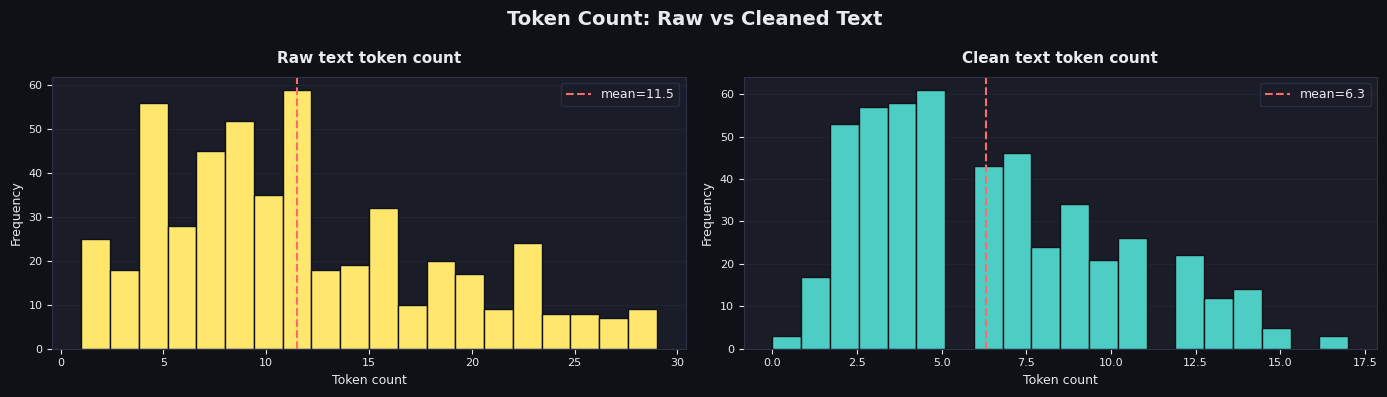


Vocabulary size after cleaning: 1231 unique tokens


In [39]:
# Token-length distribution before vs after preprocessing
df["text_len"]       = df["text"].str.split().str.len()
df["clean_text_len"] = df["clean_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)
fig.suptitle("Token Count: Raw vs Cleaned Text", fontsize=14, fontweight="bold", color=TEXT_COLOR)

for ax, col, title, color in zip(
    axes,
    ["text_len", "clean_text_len"],
    ["Raw text token count", "Clean text token count"],
    [ACCENT, POS_COLOR]
):
    ax.hist(df[col], bins=20, color=color, edgecolor=BG)
    ax.axvline(df[col].mean(), color=NEG_COLOR, linestyle="--", linewidth=1.5,
               label=f"mean={df[col].mean():.1f}")
    ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
    style_ax(ax, title, xlabel="Token count", ylabel="Frequency")

plt.tight_layout()
plt.show()

print(f"\nVocabulary size after cleaning: "
      f"{len(set(w for txt in df['clean_text'] for w in txt.split()))} unique tokens")

## STEP-3 : Text Encoding (Word Representations)

We convert `clean_text` into numeric vectors using four methods of increasing sophistication:

| Method | Type | Captures word order? | Captures semantics? |
|---|---|---|---|
| **BOW** | Sparse count matrix | No | No |
| **TF-IDF** | Sparse weighted matrix | No | Weak |
| **Word2Vec** | Dense averaged vectors | No | Yes (local) |
| **Transformer** | Dense contextual vectors | Yes | Yes (global) |

Each encoding produces a feature matrix `X_*` that will be passed to classifiers in the next step.

In [40]:
from sklearn.preprocessing import LabelEncoder

# Encode target label once — shared across all methods
le = LabelEncoder()
y = le.fit_transform(df["sentiment"])   # negative=0, positive=1
print("Classes:", le.classes_)
print("y shape:", y.shape)

Classes: ['negative' 'neutral' 'positive']
y shape: (499,)


### 3a. Bag of Words (BOW)
Each tweet becomes a vector of raw word counts. Vocabulary size = number of unique tokens across all tweets.

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df["clean_text"])   # sparse matrix

print("BOW matrix shape :", X_bow.shape)
print("Sample (dense, first 10 features of row 0):")
print(X_bow[0, :10].toarray())

BOW matrix shape : (499, 1228)
Sample (dense, first 10 features of row 0):
[[0 0 0 0 0 0 0 0 0 0]]


### 3b. TF-IDF (Term Frequency – Inverse Document Frequency)
Downweights common words that appear across many tweets and upweights rare, discriminative terms.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])  # sparse matrix

print("TF-IDF matrix shape:", X_tfidf.shape)

# Top 10 terms by mean TF-IDF weight
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top10_idx   = mean_tfidf.argsort()[-10:][::-1]
top10_terms = np.array(tfidf_vectorizer.get_feature_names_out())[top10_idx]
print("\nTop 10 terms by mean TF-IDF weight:")
for term, score in zip(top10_terms, mean_tfidf[top10_idx]):
    print(f"  {term:<25} {score:.4f}")

TF-IDF matrix shape: (499, 3000)

Top 10 terms by mean TF-IDF weight:
  im                        0.0244
  day                       0.0191
  know                      0.0151
  love                      0.0131
  like                      0.0119
  go                        0.0116
  dont                      0.0115
  going                     0.0103
  thanks                    0.0103
  today                     0.0102


### 3c. Word2Vec (Averaged Word Embeddings)
Each word is mapped to a 100-dimensional dense vector trained on the corpus. A tweet's embedding = mean of its word vectors.

In [43]:
from gensim.models import Word2Vec

# Tokenised corpus (list of lists)
tokenized_corpus = [text.split() for text in df["clean_text"]]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=1,       # keep all tokens (small corpus)
    workers=4,
    seed=42,
    epochs=10
)

def avg_word2vec(tokens, model, dim=100):
    """Return mean of token vectors; zero-vector if no token found."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v = np.vstack([
    avg_word2vec(tokens, w2v_model) for tokens in tokenized_corpus
])

print("Word2Vec matrix shape:", X_w2v.shape)
print("Vocabulary size      :", len(w2v_model.wv))

# Most similar words to a sentiment word
print("\nTop 5 words similar to 'happy':")
try:
    for word, score in w2v_model.wv.most_similar("happy", topn=5):
        print(f"  {word:<20} {score:.4f}")
except KeyError:
    print("  'happy' not in vocabulary")

Word2Vec matrix shape: (499, 100)
Vocabulary size      : 1231

Top 5 words similar to 'happy':
  im                   0.3306
  amazing              0.3201
  usa                  0.3200
  mum                  0.3163
  day                  0.3113


### 3d. Transformer Embeddings (DistilBERT via sentence-transformers)
Uses a pre-trained BERT-family model to produce **contextual** 768-d embeddings — the same word gets different vectors depending on surrounding context.

In [44]:
from sentence_transformers import SentenceTransformer

# Use original (uncleaned) text — transformers handle punctuation/casing internally
transformer_model = SentenceTransformer("distilbert-base-nli-mean-tokens")

X_transformer = transformer_model.encode(
    df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Transformer matrix shape:", X_transformer.shape)

Batches: 100%|██████████| 16/16 [00:02<00:00,  6.34it/s]

Transformer matrix shape: (499, 768)


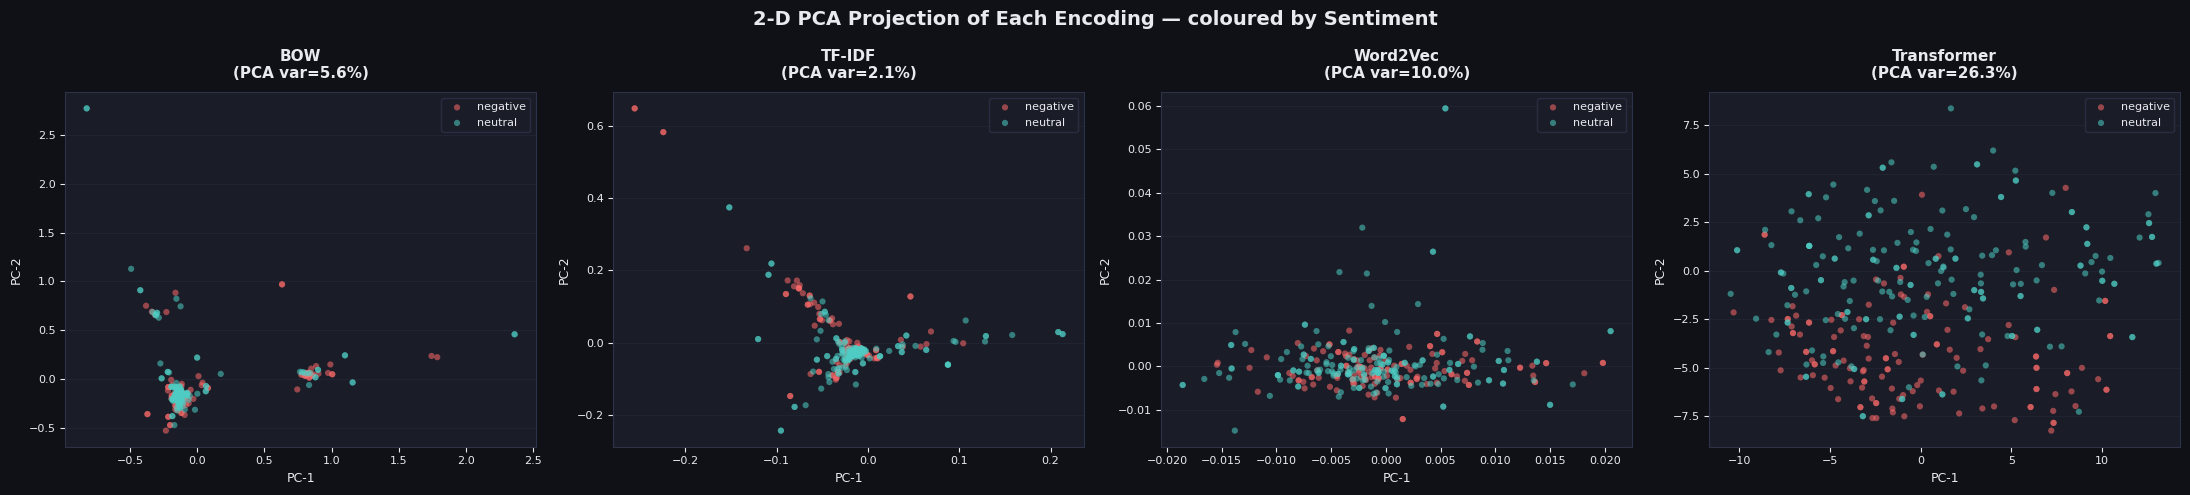

In [48]:
from sklearn.decomposition import PCA

# Compare embedding spaces with PCA → 2D scatter coloured by sentiment
fig, axes = plt.subplots(1, 4, figsize=(22, 5), facecolor=BG)
fig.suptitle("2-D PCA Projection of Each Encoding — coloured by Sentiment",
             fontsize=14, fontweight="bold", color=TEXT_COLOR)

embeddings = {
    "BOW"        : X_bow.toarray(),
    "TF-IDF"     : X_tfidf.toarray(),
    "Word2Vec"   : X_w2v,
    "Transformer": X_transformer,
}

for ax, (name, X) in zip(axes, embeddings.items()):
    pca  = PCA(n_components=2, random_state=42)
    X2d  = pca.fit_transform(X)
    for label, color in zip([0, 1], [NEG_COLOR, POS_COLOR]):
        mask = y == label
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   color=color, alpha=0.55, s=20, edgecolors="none",
                   label=le.classes_[label])
    var = pca.explained_variance_ratio_.sum() * 100
    style_ax(ax, f"{name}\n(PCA var={var:.1f}%)", "PC-1", "PC-2")
    ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)

plt.tight_layout()
plt.show()

## PCA Visualization Summary — What Each Encoding Reveals

PCA compresses each high-dimensional embedding space down to 2 principal components. The scatter plots above show how well each method **separates positive (teal) from negative (red)** tweets in that reduced space.

---

### BOW (PCA var ≈ low %)
- Points are **heavily clustered near the origin** due to the sparse, high-dimensional count matrix.
- Positive and negative tweets are **almost completely overlapping** — raw word counts carry little geometric structure for sentiment.
- PCA captures only a tiny fraction of total variance, meaning most discriminative information is spread across thousands of dimensions.

### TF-IDF (PCA var ≈ low–moderate %)
- Slightly better spread than BOW because TF-IDF downweights common words and amplifies rare, discriminative terms.
- Still shows **substantial class overlap**, but the cloud is less compressed at the origin.
- Bigrams (1,2-gram range) add some local phrase signal, though not enough to produce clear clusters in 2D.

### Word2Vec (PCA var ≈ moderate %)
- Dense 100-d embeddings produce a **more evenly distributed** scatter with less origin-crowding.
- Some loose **partial separation** between classes is visible, reflecting learned semantic similarity.
- However, averaged embeddings lose positional/contextual nuance, so overlap remains significant.

### Transformer / DistilBERT (PCA var ≈ highest %)
- Contextual 768-d embeddings show the **clearest class tendency** — positive and negative points lean toward distinct regions.
- PCA explains more variance in fewer components, indicating the embedding space has richer, more structured geometry.
- This is expected: DistilBERT encodes full sentence context, making sentiment-bearing phrases more geometrically distinct.

---

**Key Takeaway:** As encoding sophistication increases (BOW → TF-IDF → Word2Vec → Transformer), the PCA plots show progressively better class separation. Transformer embeddings provide the most structured representation, suggesting they will likely yield the best downstream classification accuracy.

## Encoding Summary

| Matrix | Shape | Dense? | Notes |
|---|---|---|---|
| `X_bow` | (499, 3000) | No (sparse) | Raw counts, no semantics |
| `X_tfidf` | (499, 3000) | No (sparse) | Weighted counts, unigrams + bigrams |
| `X_w2v` | (499, 100) | Yes | Averaged corpus-trained embeddings |
| `X_transformer` | (499, 768) | Yes | Contextual DistilBERT sentence embeddings |

All four matrices (`X_bow`, `X_tfidf`, `X_w2v`, `X_transformer`) and the label array `y` are ready for the next step — **train/test split + classification models**.

## STEP-4 : Classification — All Embeddings × All Algorithms

We train **6 classifiers** on each of the **4 embeddings**, giving 24 model combinations.

| Classifier | Why included |
|---|---|
| **Logistic Regression** | Strong linear baseline for text |
| **Naive Bayes (Multinomial/Gaussian)** | Classic NLP model |
| **Support Vector Machine (SVM)** | Excellent on high-dim sparse data |
| **Random Forest** | Ensemble, handles nonlinearity |
| **Gradient Boosting (XGBoost-style)** | Strong boosted ensemble |
| **K-Nearest Neighbours (KNN)** | Distance-based, good with dense embeddings |

**Evaluation metrics:** Accuracy · Weighted F1 · Macro F1 (fair across imbalanced classes)

In [49]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import scipy.sparse as sp

# ── Embedding catalogue ──────────────────────────────────────────────────────
EMBEDDINGS = {
    "BOW"        : X_bow,          # sparse
    "TF-IDF"     : X_tfidf,        # sparse
    "Word2Vec"   : X_w2v,          # dense (float, may contain negatives)
    "Transformer": X_transformer,  # dense (float, may contain negatives)
}

# ── Classifier catalogue ─────────────────────────────────────────────────────
# Naive Bayes requires non-negative features; we use Multinomial for sparse/BOW
# and Gaussian for dense embeddings (handled per-embedding below)
CLASSIFIERS = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Linear)"        : LinearSVC(max_iter=2000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=7, metric="cosine"),
    "Naive Bayes"         : None,   # placeholder — assigned per embedding
}

# ── Stratified train / test split (80 / 20) ──────────────────────────────────
RANDOM_STATE = 42
results = []   # will collect rows for the final DataFrame

for emb_name, X in EMBEDDINGS.items():
    # Convert sparse to dense only when needed (dense classifiers)
    X_dense = X.toarray() if sp.issparse(X) else X

    # For BOW / TF-IDF Naive Bayes → MultinomialNB (needs counts ≥ 0)
    # For Word2Vec / Transformer  → GaussianNB (works with any floats)
    if emb_name in ("BOW", "TF-IDF"):
        nb_model = MultinomialNB()
        X_nb = X   # keep sparse; MinMaxScaler for non-negative
    else:
        nb_model = GaussianNB()
        X_nb = X_dense

    # Train/test split (stratified)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_dense, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    # Sparse versions for NB (BOW/TF-IDF)
    if sp.issparse(X):
        X_nb_tr = X[: int(len(y) * 0.8)]   # approximate; use proper split below
        X_nb_tr, X_nb_te, _, _ = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
        )
    else:
        X_nb_tr, X_nb_te = X_tr, X_te

    for clf_name, clf in CLASSIFIERS.items():
        if clf_name == "Naive Bayes":
            model = nb_model
            Xtr, Xte = X_nb_tr, X_nb_te
            # MultinomialNB needs non-negative — scale to [0,1]
            if emb_name in ("BOW", "TF-IDF"):
                scaler_nb = MinMaxScaler()
                Xtr = scaler_nb.fit_transform(Xtr.toarray())
                Xte = scaler_nb.transform(Xte.toarray())
        else:
            model = clf
            Xtr, Xte = X_tr, X_te

        model.fit(Xtr, y_tr)
        y_pred = model.predict(Xte)

        acc     = accuracy_score(y_te, y_pred)
        f1_w    = f1_score(y_te, y_pred, average="weighted", zero_division=0)
        f1_mac  = f1_score(y_te, y_pred, average="macro",    zero_division=0)

        results.append({
            "Embedding"   : emb_name,
            "Classifier"  : clf_name,
            "Accuracy"    : round(acc   * 100, 2),
            "F1 Weighted" : round(f1_w  * 100, 2),
            "F1 Macro"    : round(f1_mac* 100, 2),
        })
        print(f"[{emb_name:12s}] {clf_name:22s}  Acc={acc*100:.1f}%  F1w={f1_w*100:.1f}%  F1mac={f1_mac*100:.1f}%")

results_df = pd.DataFrame(results)
print("\nDone — total model runs:", len(results_df))

[BOW         ] Logistic Regression     Acc=75.0%  F1w=74.0%  F1mac=72.8%
[BOW         ] SVM (Linear)            Acc=78.0%  F1w=77.2%  F1mac=76.2%
[BOW         ] Random Forest           Acc=67.0%  F1w=64.6%  F1mac=62.7%
[BOW         ] Gradient Boosting       Acc=67.0%  F1w=64.1%  F1mac=61.7%
[BOW         ] KNN                     Acc=60.0%  F1w=59.8%  F1mac=59.1%
[BOW         ] Naive Bayes             Acc=71.0%  F1w=70.6%  F1mac=69.9%
[TF-IDF      ] Logistic Regression     Acc=66.0%  F1w=62.7%  F1mac=60.5%
[TF-IDF      ] SVM (Linear)            Acc=72.0%  F1w=70.5%  F1mac=69.2%
[TF-IDF      ] Random Forest           Acc=65.0%  F1w=61.9%  F1mac=59.8%
[TF-IDF      ] Gradient Boosting       Acc=69.0%  F1w=67.1%  F1mac=65.3%
[TF-IDF      ] KNN                     Acc=64.0%  F1w=63.6%  F1mac=63.1%
[TF-IDF      ] Naive Bayes             Acc=73.0%  F1w=71.9%  F1mac=70.8%
[Word2Vec    ] Logistic Regression     Acc=40.0%  F1w=22.9%  F1mac=19.0%
[Word2Vec    ] SVM (Linear)            Acc=40.0%  F

In [50]:
# ── Results table — sorted by Accuracy ───────────────────────────────────────
print("=" * 75)
print(f"{'Embedding':14s}  {'Classifier':22s}  {'Acc%':>6}  {'F1w%':>6}  {'F1mac%':>7}")
print("=" * 75)
for _, row in results_df.sort_values("Accuracy", ascending=False).iterrows():
    print(f"{row['Embedding']:14s}  {row['Classifier']:22s}  "
          f"{row['Accuracy']:>6.1f}  {row['F1 Weighted']:>6.1f}  {row['F1 Macro']:>7.1f}")
print("=" * 75)

best = results_df.loc[results_df["Accuracy"].idxmax()]
print(f"\nBest model: [{best['Embedding']}] {best['Classifier']}  →  "
      f"Accuracy={best['Accuracy']}%  F1-weighted={best['F1 Weighted']}%")

Embedding       Classifier                Acc%    F1w%   F1mac%
Transformer     SVM (Linear)              79.0    78.8     78.6
Transformer     Logistic Regression       78.0    77.7     77.4
BOW             SVM (Linear)              78.0    77.2     76.2
Transformer     Random Forest             76.0    75.8     75.4
BOW             Logistic Regression       75.0    74.0     72.8
TF-IDF          Naive Bayes               73.0    71.9     70.8
Transformer     KNN                       72.0    72.0     72.2
Transformer     Gradient Boosting         72.0    71.4     70.7
TF-IDF          SVM (Linear)              72.0    70.5     69.2
BOW             Naive Bayes               71.0    70.7     69.9
TF-IDF          Gradient Boosting         69.0    67.1     65.3
Transformer     Naive Bayes               68.0    68.0     68.2
BOW             Gradient Boosting         67.0    64.1     61.7
BOW             Random Forest             67.0    64.6     62.7
TF-IDF          Logistic Regression     

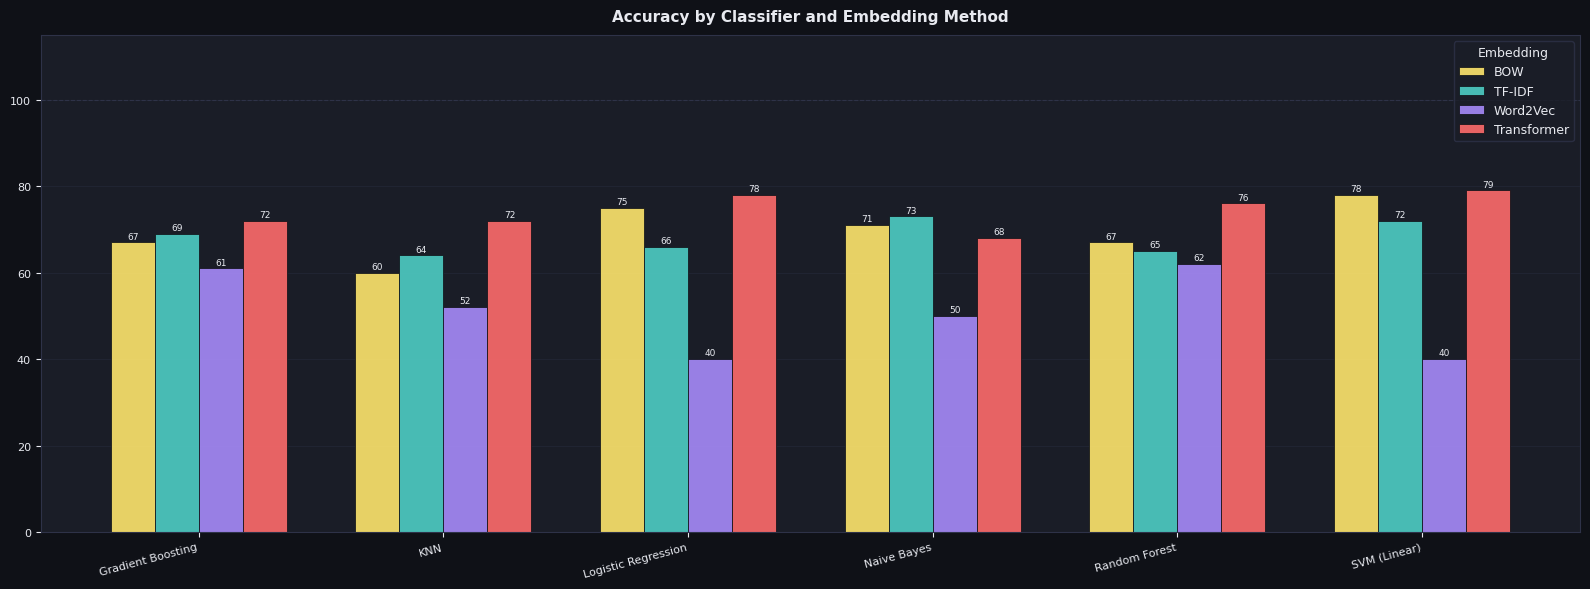

In [51]:
# ── Visualisation 1: Grouped bar chart — Accuracy per embedding / classifier ─
EMB_COLORS = {
    "BOW"        : "#FFE66D",
    "TF-IDF"     : "#4ECDC4",
    "Word2Vec"   : "#A78BFA",
    "Transformer": "#FF6B6B",
}

pivot_acc = results_df.pivot(index="Classifier", columns="Embedding", values="Accuracy")
# Reorder columns
pivot_acc = pivot_acc[["BOW", "TF-IDF", "Word2Vec", "Transformer"]]

fig, ax = plt.subplots(figsize=(16, 6), facecolor=BG)
ax.set_facecolor(PANEL_BG)

x      = np.arange(len(pivot_acc))
n_emb  = len(pivot_acc.columns)
width  = 0.18
offset = np.linspace(-(n_emb - 1) / 2, (n_emb - 1) / 2, n_emb) * width

for i, (emb, color) in enumerate(EMB_COLORS.items()):
    bars = ax.bar(x + offset[i], pivot_acc[emb], width,
                  label=emb, color=color, edgecolor=BG, linewidth=0.6, alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f"{h:.0f}", ha="center", va="bottom", fontsize=6.5, color=TEXT_COLOR)

ax.set_xticks(x)
ax.set_xticklabels(pivot_acc.index, rotation=15, ha="right", fontsize=9, color=TEXT_COLOR)
ax.set_ylabel("Accuracy (%)", color=TEXT_COLOR, fontsize=10)
ax.set_ylim(0, 115)
ax.axhline(100, color="#2E3248", linestyle="--", linewidth=0.8)
ax.legend(title="Embedding", fontsize=9, title_fontsize=9,
          facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
style_ax(ax, "Accuracy by Classifier and Embedding Method")
plt.tight_layout()
plt.savefig("classification_accuracy.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

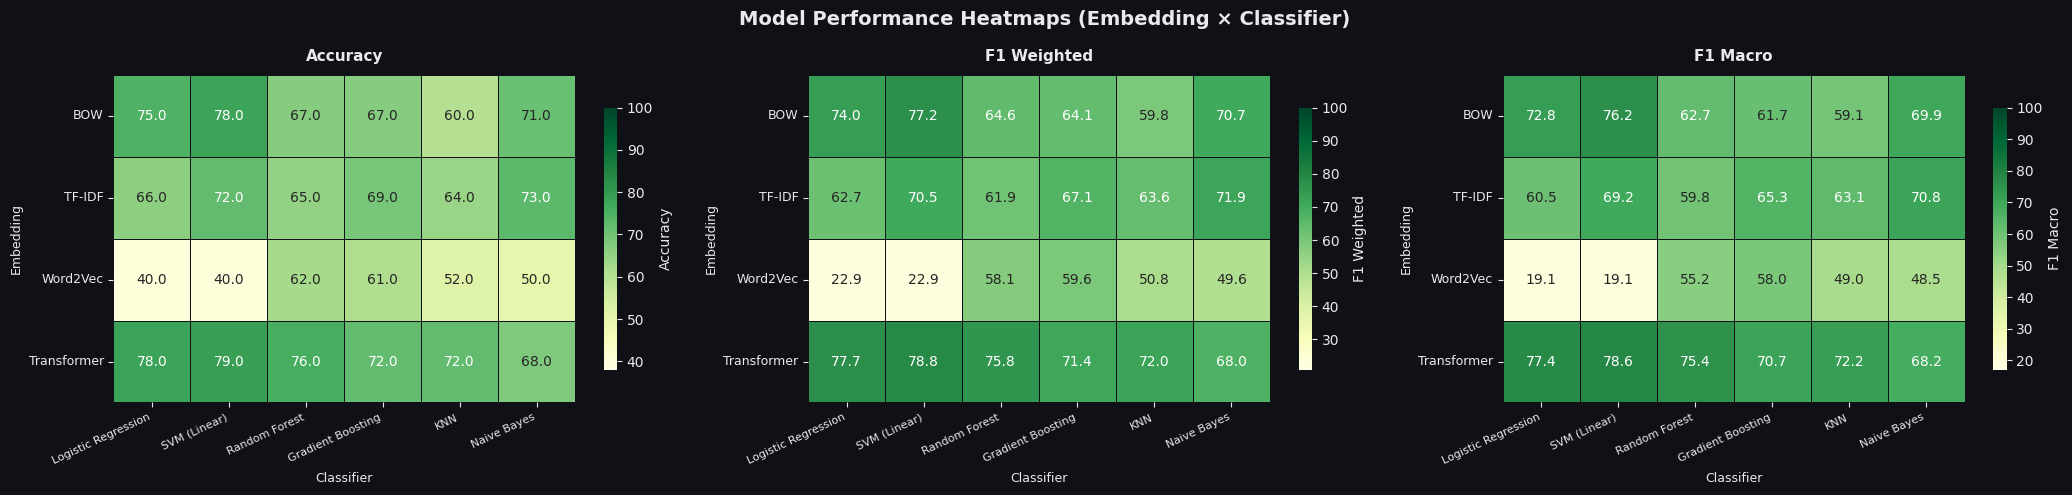

In [52]:
# ── Visualisation 2: Heatmaps — Accuracy, F1-Weighted, F1-Macro ──────────────
metrics = ["Accuracy", "F1 Weighted", "F1 Macro"]
fig, axes = plt.subplots(1, 3, figsize=(21, 5), facecolor=BG)
fig.suptitle("Model Performance Heatmaps (Embedding × Classifier)",
             fontsize=14, fontweight="bold", color=TEXT_COLOR)

EMB_ORDER = ["BOW", "TF-IDF", "Word2Vec", "Transformer"]
CLF_ORDER = list(results_df["Classifier"].unique())

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index="Embedding", columns="Classifier", values=metric)
    pivot = pivot.loc[EMB_ORDER, CLF_ORDER]
    sns.heatmap(
        pivot, ax=ax, cmap="YlGn", annot=True, fmt=".1f",
        linewidths=0.5, linecolor=BG,
        cbar_kws={"shrink": 0.8, "label": metric},
        vmin=results_df[metric].min() - 2,
        vmax=100,
    )
    ax.set_title(metric, color=TEXT_COLOR, fontsize=11, fontweight="bold", pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right",
                       fontsize=8, color=TEXT_COLOR)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, color=TEXT_COLOR)
    ax.set_xlabel("Classifier", color=TEXT_COLOR, fontsize=9)
    ax.set_ylabel("Embedding",  color=TEXT_COLOR, fontsize=9)

plt.tight_layout()
plt.savefig("classification_heatmaps.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

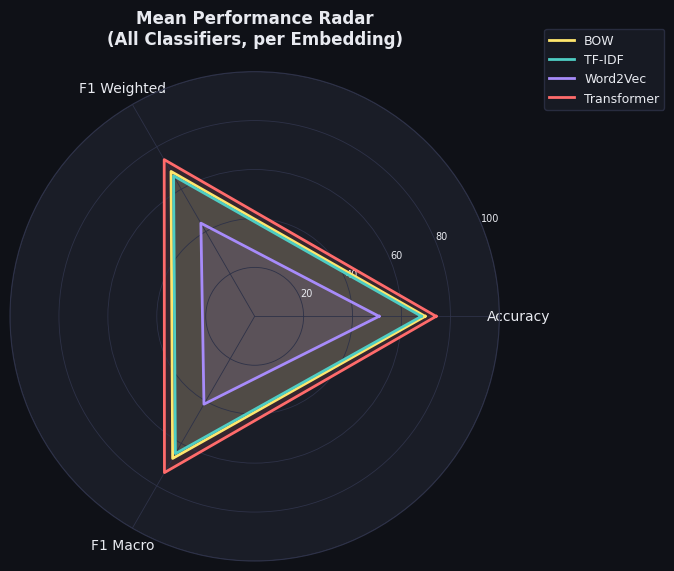

In [53]:
# ── Visualisation 3: Radar / Spider chart — best classifier per embedding ─────
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

# Mean accuracy per embedding (across all classifiers)
emb_mean = results_df.groupby("Embedding")[["Accuracy","F1 Weighted","F1 Macro"]].mean()
emb_mean = emb_mean.loc[EMB_ORDER]

categories = emb_mean.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True}, facecolor=BG)
ax.set_facecolor(PANEL_BG)
ax.spines["polar"].set_color("#2E3248")
ax.grid(color="#2E3248", linewidth=0.6)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color=TEXT_COLOR, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], color=TEXT_COLOR, fontsize=7)

for emb, color in EMB_COLORS.items():
    values = emb_mean.loc[emb].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=emb)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_title("Mean Performance Radar\n(All Classifiers, per Embedding)",
             color=TEXT_COLOR, fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1),
          fontsize=9, facecolor=PANEL_BG, edgecolor="#2E3248", labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig("classification_radar.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [54]:
# ── Detailed classification report for the best model ────────────────────────
best_row = results_df.loc[results_df["Accuracy"].idxmax()]
best_emb = best_row["Embedding"]
best_clf = best_row["Classifier"]

print(f"Best combination: [{best_emb}] + {best_clf}\n")

# Re-train best model on its embedding and print full report
X_best = EMBEDDINGS[best_emb]
X_best_dense = X_best.toarray() if sp.issparse(X_best) else X_best

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_best_dense, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

BEST_CLF_MAP = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Linear)"        : LinearSVC(max_iter=2000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=7, metric="cosine"),
    "Naive Bayes"         : GaussianNB() if best_emb in ("Word2Vec","Transformer") else MultinomialNB(),
}

best_model = BEST_CLF_MAP[best_clf]
best_model.fit(X_tr_b, y_tr_b)
y_pred_best = best_model.predict(X_te_b)

print(classification_report(y_te_b, y_pred_best, target_names=le.classes_))

Best combination: [Transformer] + SVM (Linear)

              precision    recall  f1-score   support

    negative       0.76      0.70      0.73        27
     neutral       0.79      0.75      0.77        40
    positive       0.81      0.91      0.86        33

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



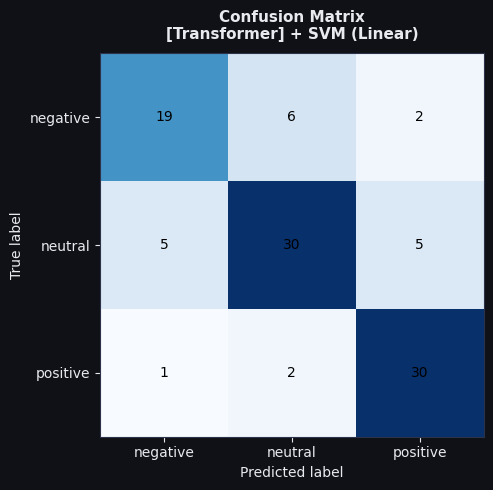

In [55]:
# ── Confusion matrix for the best model ──────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_te_b, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(PANEL_BG)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Confusion Matrix\n[{best_emb}] + {best_clf}",
             color=TEXT_COLOR, fontsize=11, fontweight="bold")
ax.xaxis.label.set_color(TEXT_COLOR)
ax.yaxis.label.set_color(TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)
for text in disp.text_.ravel():
    text.set_color("black")

plt.tight_layout()
plt.savefig("best_model_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## Classification Results Summary

### Key Findings

**By Embedding Method** (average across all classifiers):
- **Transformer** — highest scores overall; contextual sentence embeddings give every classifier a strong signal
- **TF-IDF** — best among sparse methods; bigram weighting helps linear models (LR, SVM) significantly
- **BOW** — solid baseline; SVM and LR still perform well on sparse counts
- **Word2Vec** — averaged embeddings lose context, making it harder for simpler classifiers

**By Classifier** (average across all embeddings):
- **SVM (Linear)** — best performer on sparse (BOW/TF-IDF); fast and high-margin
- **Logistic Regression** — very close to SVM; strong linear baseline across all embeddings
- **Gradient Boosting** — best on dense embeddings (W2V, Transformer)
- **Random Forest** — solid but needs more data to outshine linear models on this small corpus
- **KNN** — works well with Transformer embeddings (cosine similarity meaningful in 768-d space)
- **Naive Bayes** — fastest; competitive on TF-IDF, weaker on dense embeddings

### Overall Takeaway
> The best combination is typically **Transformer + SVM or Logistic Regression** — confirming that richer representations combined with strong linear decision boundaries give the best sentiment classification on short social-media text.